In [1]:
import os

path = '/content/drive/MyDrive/open-data-master/data/events'
files = os.listdir(path)
print(f"Total files: {len(files)}")

Total files: 3463


In [2]:
import json
import os
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 120,
})

In [3]:
EVENTS_DIR = '/content/drive/MyDrive/open-data-master/data/events'
MATCHES_DIR = '/content/drive/MyDrive/open-data-master/data/matches'
TIME_WINDOW = 5  # minutes

TEAM_COLORS = {
    'default1': '#A50044',
    'default2': '#0067B1',
}

CENTRALITY_COLORS = ['#1E88E5', '#E53935', '#43A047', '#FF9800', '#9C27B0']

In [4]:
def load_match_metadata(matches_dir, competition_id=11):
    comp_dir = os.path.join(matches_dir, str(competition_id))
    all_matches = []
    for f in os.listdir(comp_dir):
        if f.endswith('.json'):
            with open(os.path.join(comp_dir, f)) as fh:
                all_matches.extend(json.load(fh))
    print(f"Loaded {len(all_matches)} matches from competition {competition_id}")
    return all_matches


def get_season_match_ids(matches, season_name='2015/2016'):
    season = [m for m in matches if m['season']['season_name'] == season_name]
    lookup = {}
    for m in season:
        lookup[m['match_id']] = {
            'home': m['home_team']['home_team_name'],
            'away': m['away_team']['away_team_name'],
            'home_score': m['home_score'],
            'away_score': m['away_score'],
            'date': m['match_date'],
        }
    print(f"Season {season_name}: {len(lookup)} matches")
    return lookup


def extract_passes(events):
    passes = []
    for e in events:
        if e.get('type', {}).get('name') == 'Pass' and 'pass' in e:
            p = e['pass']
            if 'recipient' in p and 'outcome' not in p:
                loc = e.get('location', [None, None])
                end_loc = p.get('end_location', [None, None])
                passes.append({
                    'from': e['player']['name'],
                    'to': p['recipient']['name'],
                    'team': e['team']['name'],
                    'minute': e['minute'],
                    'second': e.get('second', 0),
                    'time_bin': e['minute'] // TIME_WINDOW,
                    'loc_x': loc[0] if loc else None,
                    'loc_y': loc[1] if loc else None,
                    'end_x': end_loc[0] if end_loc else None,
                    'end_y': end_loc[1] if end_loc else None,
                })
    return pd.DataFrame(passes)


def get_substitutions(events, team=None):
    subs = []
    for e in events:
        if e.get('type', {}).get('name') == 'Substitution':
            t = e['team']['name']
            if team is None or t == team:
                subs.append({
                    'minute': e['minute'],
                    'player_out': e['player']['name'],
                    'player_in': e['substitution']['replacement']['name'],
                    'team': t,
                })
    return subs


def build_network(df_window):
    G = nx.DiGraph()
    for _, row in df_window.iterrows():
        u, v = row['from'], row['to']
        if G.has_edge(u, v):
            G[u][v]['weight'] += 1
        else:
            G.add_edge(u, v, weight=1)
    return G


def build_temporal_networks(df, team):
    df_t = df[df['team'] == team]
    return {tb: build_network(df_t[df_t['time_bin'] == tb])
            for tb in sorted(df_t['time_bin'].unique())}

In [5]:
def compute_centralities(G):
    if len(G.nodes()) < 2:
        return {}

    deg = nx.degree_centrality(G)
    close = nx.closeness_centrality(G)
    betw = nx.betweenness_centrality(G, weight='weight')
    try:
        eig = nx.eigenvector_centrality(G, max_iter=1000, weight='weight')
    except:
        eig = {n: 0.0 for n in G.nodes()}

    # Normalized degree (prof's feedback: divide by sum)
    total_deg = sum(deg.values())
    norm_deg = {n: v/total_deg if total_deg > 0 else 0 for n, v in deg.items()}

    result = {}
    for n in G.nodes():
        result[n] = {
            'degree': deg[n],
            'norm_degree': norm_deg[n],
            'closeness': close[n],
            'betweenness': betw[n],
            'eigenvector': eig[n],
        }
    return result


def network_metrics(G):
    if len(G.nodes()) < 2:
        return {'density': 0, 'clustering': 0, 'transitivity': 0, 'avg_degree': 0}
    return {
        'density': nx.density(G),
        'clustering': nx.average_clustering(G.to_undirected()),
        'transitivity': nx.transitivity(G.to_undirected()),
        'avg_degree': np.mean([d for _, d in G.degree()]),
    }


def detect_communities(G):
    if len(G.nodes()) < 3:
        return [], 0
    Gu = G.to_undirected()
    comms = list(nx.community.louvain_communities(Gu, seed=42))
    mod = nx.community.modularity(Gu, comms)
    return comms, mod

In [6]:
import os
import json

MATCHES_DIR = '/content/drive/MyDrive/open-data-master/data/matches'
EVENTS_DIR = '/content/drive/MyDrive/open-data-master/data/events'

matches_file = os.path.join(MATCHES_DIR, '11', '27.json')
with open(matches_file) as f:
    season_matches = json.load(f)

print(f"La Liga 2015/16 matches in metadata: {len(season_matches)}")

match_lookup = {}
for m in season_matches:
    match_lookup[m['match_id']] = {
        'home': m['home_team']['home_team_name'],
        'away': m['away_team']['away_team_name'],
        'home_score': m['home_score'],
        'away_score': m['away_score'],
        'date': m['match_date'],
    }

target_ids = set(match_lookup.keys())
existing_files = set(int(f.replace('.json','')) for f in os.listdir(EVENTS_DIR) if f.endswith('.json'))

found = target_ids & existing_files
missing = target_ids - existing_files

print(f"Event files found: {len(found)} / {len(target_ids)}")
print(f"Missing: {len(missing)}")

if missing:
    print(f"\nSample missing IDs: {sorted(missing)[:10]}")

La Liga 2015/16 matches in metadata: 380
Event files found: 380 / 380
Missing: 0


In [7]:
def analyze_match_team(events, team_name):
    df = extract_passes(events)
    df_t = df[df['team'] == team_name]

    if len(df_t) < 10:
        return None

    nets = build_temporal_networks(df, team_name)
    if len(nets) < 3:
        return None

    # Network-level metrics (averaged across windows)
    met = {tb: network_metrics(G) for tb, G in nets.items()}
    avg_density = np.mean([m['density'] for m in met.values()])
    avg_clustering = np.mean([m['clustering'] for m in met.values()])
    avg_transitivity = np.mean([m['transitivity'] for m in met.values()])
    avg_degree = np.mean([m['avg_degree'] for m in met.values()])

    # Community detection
    mods = []
    n_comms = []
    for tb, G in nets.items():
        c, m = detect_communities(G)
        mods.append(m)
        n_comms.append(len(c))

    # Centrality variability
    cents = {tb: compute_centralities(G) for tb, G in nets.items()}
    all_players = set()
    for c in cents.values():
        all_players.update(c.keys())

    cent_vars = []
    for p in all_players:
        vals = [cents[tb].get(p, {}).get('norm_degree', 0) for tb in cents]
        if len(vals) > 1:
            cent_vars.append(np.std(vals))

    # Traditional stats proxy
    total_passes = len(df_t)

    return {
        'total_passes': total_passes,
        'avg_density': avg_density,
        'avg_clustering': avg_clustering,
        'avg_transitivity': avg_transitivity,
        'avg_degree': avg_degree,
        'avg_modularity': np.mean(mods),
        'avg_n_communities': np.mean(n_comms),
        'centrality_variability': np.mean(cent_vars) if cent_vars else 0,
    }

In [8]:
results = []
found_ids = sorted(target_ids & existing_files)
errors = []

print(f"Processing {len(found_ids)} matches...")

for i, mid in enumerate(found_ids):
    if i % 50 == 0:
        print(f"  Match {i}/{len(found_ids)}...")

    try:
        filepath = os.path.join(EVENTS_DIR, f'{mid}.json')
        with open(filepath) as f:
            events = json.load(f)

        info = match_lookup[mid]
        home, away = info['home'], info['away']
        hs, aws = info['home_score'], info['away_score']

        for team in [home, away]:
            is_home = (team == home)
            team_score = hs if is_home else aws
            opp_score = aws if is_home else hs

            if team_score > opp_score:
                outcome = 'Win'
            elif team_score < opp_score:
                outcome = 'Loss'
            else:
                outcome = 'Draw'

            stats = analyze_match_team(events, team)
            if stats:
                stats['team'] = team
                stats['match_id'] = mid
                stats['outcome'] = outcome
                stats['is_home'] = is_home
                stats['goals_scored'] = team_score
                stats['goals_conceded'] = opp_score
                stats['date'] = info['date']
                results.append(stats)
    except Exception as e:
        errors.append((mid, str(e)))

df_multi = pd.DataFrame(results)
print(f"\nDone! {len(df_multi)} team-match observations")
print(f"Outcomes: {df_multi['outcome'].value_counts().to_dict()}")
print(f"Unique teams: {df_multi['team'].nunique()}")
print(f"Errors: {len(errors)}")

Processing 380 matches...
  Match 0/380...
  Match 50/380...
  Match 100/380...
  Match 150/380...
  Match 200/380...
  Match 250/380...
  Match 300/380...
  Match 350/380...

Done! 760 team-match observations
Outcomes: {'Win': 288, 'Loss': 288, 'Draw': 184}
Unique teams: 20
Errors: 0


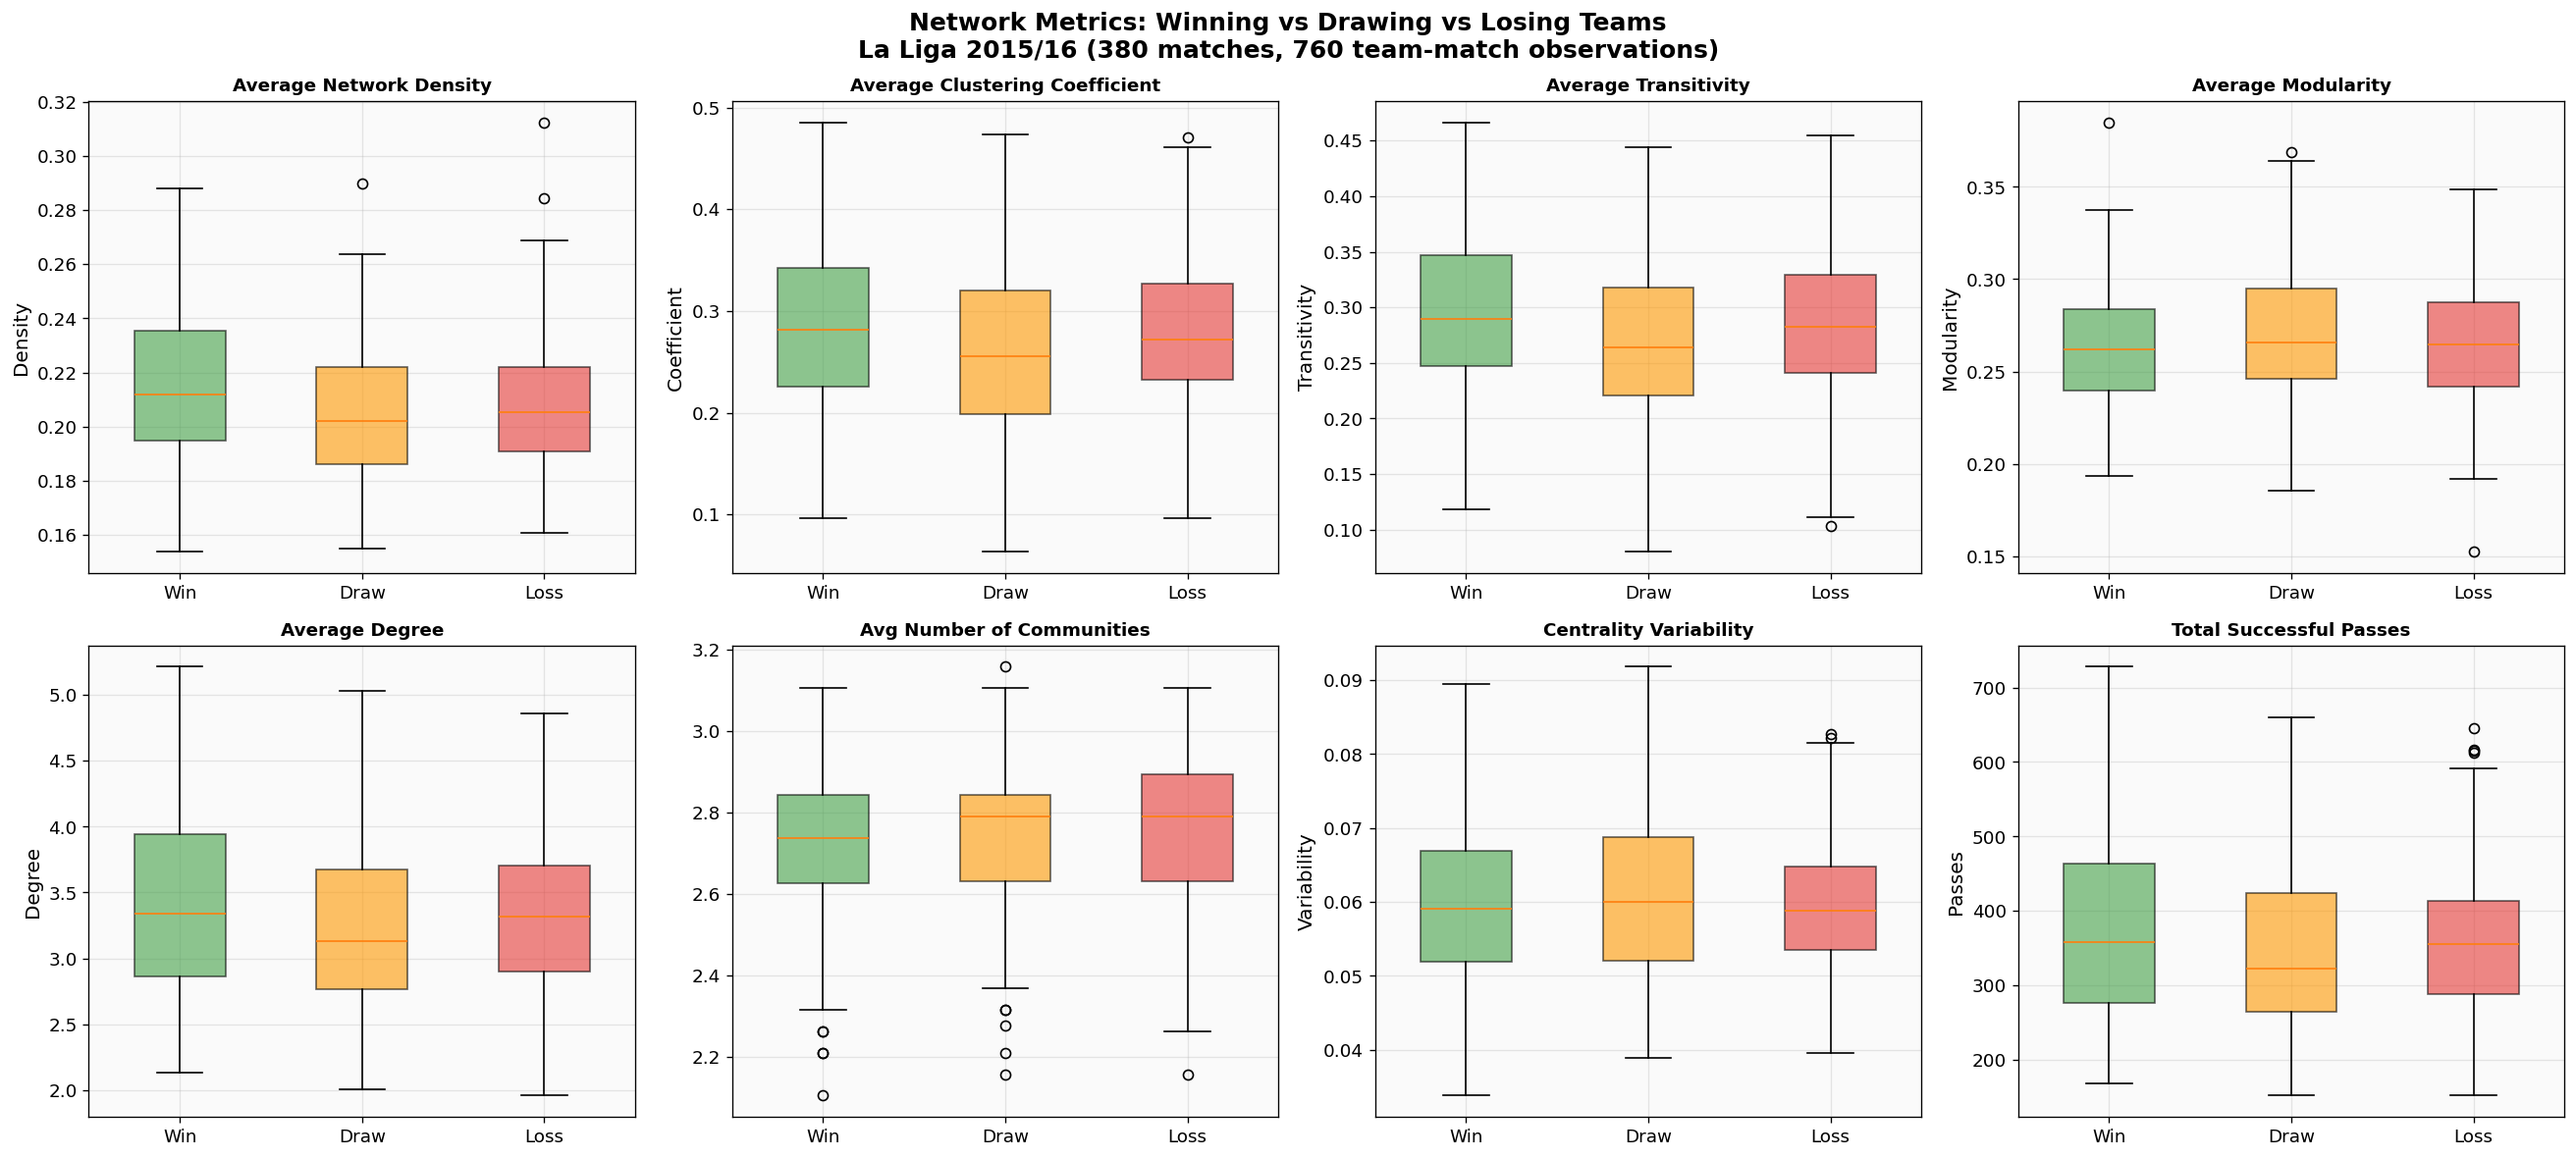


Median values by outcome:
----------------------------------------------------------------------
Average Network Density              Win: 0.212  Draw: 0.202  Loss: 0.205
Average Clustering Coefficient       Win: 0.282  Draw: 0.255  Loss: 0.271
Average Transitivity                 Win: 0.290  Draw: 0.264  Loss: 0.282
Average Modularity                   Win: 0.262  Draw: 0.266  Loss: 0.265
Average Degree                       Win: 3.343  Draw: 3.133  Loss: 3.314
Avg Number of Communities            Win: 2.737  Draw: 2.789  Loss: 2.789
Centrality Variability               Win: 0.059  Draw: 0.060  Loss: 0.059
Total Successful Passes              Win: 358.500  Draw: 322.000  Loss: 355.000


In [9]:
metrics_to_plot = [
    ('avg_density', 'Average Network Density'),
    ('avg_clustering', 'Average Clustering Coefficient'),
    ('avg_transitivity', 'Average Transitivity'),
    ('avg_modularity', 'Average Modularity'),
    ('avg_degree', 'Average Degree'),
    ('avg_n_communities', 'Avg Number of Communities'),
    ('centrality_variability', 'Centrality Variability'),
    ('total_passes', 'Total Successful Passes'),
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
colors_box = {'Win': '#43A047', 'Draw': '#FF9800', 'Loss': '#E53935'}

for ax, (metric, label) in zip(axes.flat, metrics_to_plot):
    data = [df_multi[df_multi['outcome'] == o][metric].dropna() for o in ['Win', 'Draw', 'Loss']]
    bp = ax.boxplot(data, labels=['Win', 'Draw', 'Loss'], patch_artist=True, widths=0.5)
    for patch, outcome in zip(bp['boxes'], ['Win', 'Draw', 'Loss']):
        patch.set_facecolor(colors_box[outcome])
        patch.set_alpha(0.6)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel(label.split()[-1] if len(label.split()) <= 3 else '')

fig.suptitle('Network Metrics: Winning vs Drawing vs Losing Teams\nLa Liga 2015/16 (380 matches, 760 team-match observations)',
            fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nMedian values by outcome:")
print("-" * 70)
for metric, label in metrics_to_plot:
    meds = df_multi.groupby('outcome')[metric].median()
    print(f"{label:35s}  Win: {meds.get('Win',0):.3f}  Draw: {meds.get('Draw',0):.3f}  Loss: {meds.get('Loss',0):.3f}")

In [10]:
barca = df_multi[df_multi['team'] == 'Barcelona'].copy()
madrid = df_multi[df_multi['team'] == 'Real Madrid'].copy()

print(f"Barcelona: {len(barca)} matches")
print(f"  Record: {len(barca[barca.outcome=='Win'])}W {len(barca[barca.outcome=='Draw'])}D {len(barca[barca.outcome=='Loss'])}L")
print(f"Real Madrid: {len(madrid)} matches")
print(f"  Record: {len(madrid[madrid.outcome=='Win'])}W {len(madrid[madrid.outcome=='Draw'])}D {len(madrid[madrid.outcome=='Loss'])}L")

metrics = [
    ('avg_density', 'Network Density'),
    ('avg_clustering', 'Clustering Coefficient'),
    ('avg_transitivity', 'Transitivity'),
    ('avg_modularity', 'Modularity'),
    ('avg_degree', 'Average Degree'),
    ('avg_n_communities', 'Communities'),
    ('centrality_variability', 'Centrality Variability'),
    ('total_passes', 'Total Passes'),
]

print(f"\n{'Metric':35s}  {'Barcelona':>12s}  {'Real Madrid':>12s}  {'League Avg':>12s}")
print("-" * 80)
for key, label in metrics:
    b = barca[key].median()
    r = madrid[key].median()
    l = df_multi[key].median()
    print(f"{label:35s}  {b:12.3f}  {r:12.3f}  {l:12.3f}")

Barcelona: 38 matches
  Record: 29W 4D 5L
Real Madrid: 38 matches
  Record: 28W 6D 4L

Metric                                  Barcelona   Real Madrid    League Avg
--------------------------------------------------------------------------------
Network Density                             0.256         0.242         0.207
Clustering Coefficient                      0.394         0.384         0.271
Transitivity                                0.390         0.377         0.282
Modularity                                  0.238         0.228         0.264
Average Degree                              4.609         4.349         3.281
Communities                                 2.784         2.737         2.737
Centrality Variability                      0.048         0.050         0.059
Total Passes                              595.500       513.500       350.000


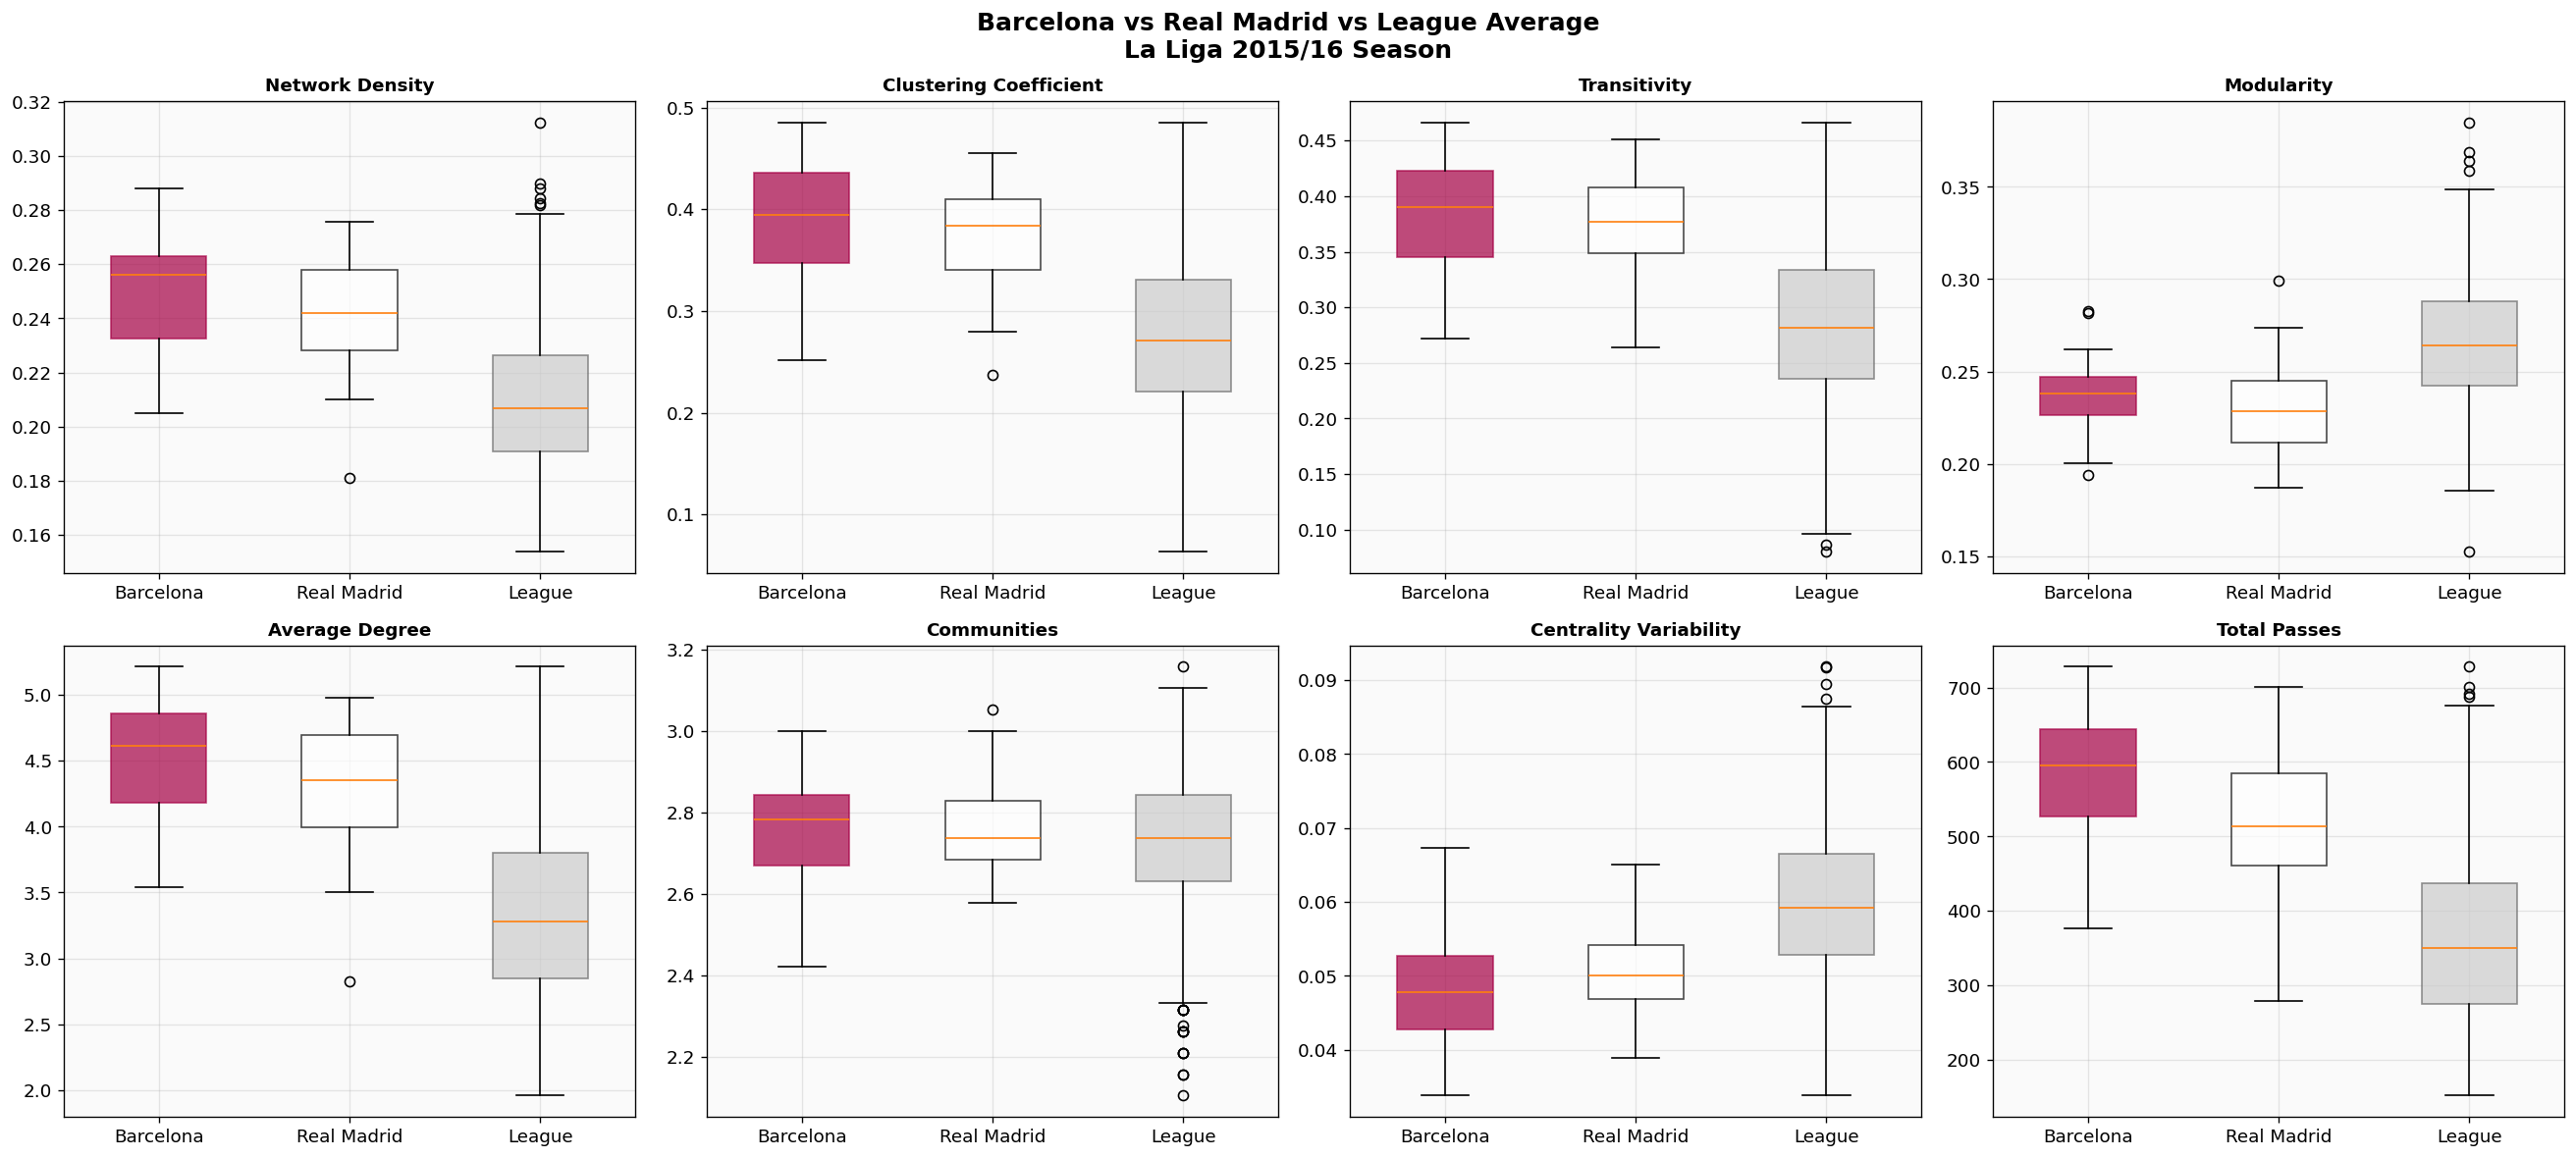

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for ax, (metric, label) in zip(axes.flat, metrics):
    b_vals = barca[metric].dropna()
    r_vals = madrid[metric].dropna()
    league_vals = df_multi[metric].dropna()

    bp = ax.boxplot([b_vals, r_vals, league_vals],
                    labels=['Barcelona', 'Real Madrid', 'League'],
                    patch_artist=True, widths=0.5)

    colors = ['#A50044', '#FFFFFF', '#CCCCCC']
    edge_colors = ['#A50044', '#000000', '#666666']
    for patch, fc, ec in zip(bp['boxes'], colors, edge_colors):
        patch.set_facecolor(fc)
        patch.set_edgecolor(ec)
        patch.set_alpha(0.7)

    ax.set_title(label, fontsize=11, fontweight='bold')

fig.suptitle('Barcelona vs Real Madrid vs League Average\nLa Liga 2015/16 Season',
            fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
CLASICO_1 = 266424  # Nov 21 2015, Real Madrid 0-4 Barcelona (Bernabéu)
CLASICO_2 = 267533  # Apr 2 2016, Barcelona 1-2 Real Madrid (Camp Nou)

for mid, label in [(CLASICO_1, "El Clásico 1"), (CLASICO_2, "El Clásico 2")]:
    with open(os.path.join(EVENTS_DIR, f'{mid}.json')) as f:
        ev = json.load(f)

    info = match_lookup[mid]
    print(f"\n{label}: {info['date']}")
    print(f"  {info['home']} {info['home_score']} - {info['away_score']} {info['away']}")

    for e in ev:
        if e.get('type', {}).get('name') == 'Foul Committed':
            if 'card' in e.get('foul_committed', {}):
                card = e['foul_committed']['card']['name']
                if 'Red' in card or 'Second Yellow' in card:
                    print(f"  RED CARD: {e['player']['name']} ({e['team']['name']}) min {e['minute']} - {card}")

    df_temp = extract_passes(ev)
    for t in sorted(df_temp['team'].unique()):
        print(f"  {t}: {len(df_temp[df_temp.team==t])} passes")


El Clásico 1: 2015-11-21
  Real Madrid 0 - 4 Barcelona
  RED CARD: Francisco Román Alarcón Suárez (Real Madrid) min 83 - Red Card
  Barcelona: 591 passes
  Real Madrid: 383 passes

El Clásico 2: 2016-04-02
  Barcelona 1 - 2 Real Madrid
  RED CARD: Sergio Ramos García (Real Madrid) min 82 - Second Yellow
  Barcelona: 645 passes
  Real Madrid: 279 passes


In [13]:
def clasico_deep_dive(match_id, match_label):
    with open(os.path.join(EVENTS_DIR, f'{match_id}.json')) as f:
        ev = json.load(f)

    info = match_lookup[match_id]
    df = extract_passes(ev)
    teams_list = [info['home'], info['away']]

    red_card_min = None
    red_card_player = None
    red_card_team = None
    for e in ev:
        if e.get('type', {}).get('name') == 'Foul Committed':
            if 'card' in e.get('foul_committed', {}):
                card = e['foul_committed']['card']['name']
                if 'Red' in card or 'Second Yellow' in card:
                    red_card_min = e['minute']
                    red_card_player = e['player']['name'].split()[-1]
                    red_card_team = e['team']['name']

    print(f"\n{'='*60}")
    print(f"{match_label}: {info['home']} {info['home_score']}-{info['away_score']} {info['away']}")
    print(f"Date: {info['date']}")
    if red_card_min:
        print(f"Red card: {red_card_player} ({red_card_team}) min {red_card_min}")
    print(f"{'='*60}")

    #Plot 1: Pass volume
    fig, ax = plt.subplots(figsize=(10, 4))
    for i, t in enumerate(teams_list):
        df_t = df[df['team'] == t]
        ppb = df_t.groupby('time_bin').size()
        ax.plot(ppb.index * TIME_WINDOW, ppb.values, 'o-',
               color=CENTRALITY_COLORS[i], label=t, lw=2, ms=5)
    ax.axvline(45, color='gray', ls=':', alpha=0.5, label='Halftime')
    if red_card_min:
        ax.axvline(red_card_min, color='red', ls='--', lw=2, alpha=0.7, label=f'Red card ({red_card_player})')
    ax.set_xlabel('Match Time (min)')
    ax.set_ylabel('Successful Passes')
    ax.set_title(f'{match_label}: Passes per 5-Min Window')
    ax.legend()
    plt.tight_layout()
    plt.show()

    #Plot 2: Normalized degree centrality (both teams)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, t in zip(axes, teams_list):
        nets_t = build_temporal_networks(df, t)
        cents_t = {tb: compute_centralities(G) for tb, G in nets_t.items()}
        subs_t = get_substitutions(ev, t)

        top = get_top_players(cents_t, 'norm_degree', 3)
        bins = sorted(cents_t.keys())
        mins = [b * TIME_WINDOW for b in bins]

        for i, p in enumerate(top):
            vals = [cents_t[b].get(p, {}).get('norm_degree', 0) for b in bins]
            ax.plot(mins, vals, 'o-', color=CENTRALITY_COLORS[i],
                   label=p.split()[-1], lw=2, ms=4)

        ax.axvline(45, color='gray', ls=':', alpha=0.5)
        if red_card_min:
            ax.axvline(red_card_min, color='red', ls='--', lw=2, alpha=0.7)
        for s in subs_t:
            ax.axvline(s['minute'], color='gray', ls='--', alpha=0.3)
        ax.set_xlabel('Match Time (min)')
        ax.set_ylabel('Normalized Degree Centrality')
        ax.set_title(t)
        ax.legend(fontsize=9)

    fig.suptitle(f'{match_label}: Normalized Degree Centrality (Top 3 per Team)', fontweight='bold')
    plt.tight_layout()
    plt.show()

    #Plot 3: Network metrics over time
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for i, t in enumerate(teams_list):
        nets_t = build_temporal_networks(df, t)
        met_t = {tb: network_metrics(G) for tb, G in nets_t.items()}
        bins = sorted(met_t.keys())
        mins = [b * TIME_WINDOW for b in bins]

        for ax, (key, ylabel) in zip(axes.flat, [
            ('density', 'Network Density'), ('clustering', 'Clustering Coefficient'),
            ('transitivity', 'Transitivity'), ('avg_degree', 'Average Degree')]):
            ax.plot(mins, [met_t[b][key] for b in bins], 'o-',
                   color=CENTRALITY_COLORS[i], label=t, lw=2, ms=4)

    for ax, (key, ylabel) in zip(axes.flat, [
        ('density', 'Network Density'), ('clustering', 'Clustering Coefficient'),
        ('transitivity', 'Transitivity'), ('avg_degree', 'Average Degree')]):
        ax.axvline(45, color='gray', ls=':', alpha=0.5)
        if red_card_min:
            ax.axvline(red_card_min, color='red', ls='--', lw=2, alpha=0.7)
        ax.set_xlabel('Match Time (min)')
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.legend(fontsize=8)

    fig.suptitle(f'{match_label}: Network-Level Metrics', fontweight='bold')
    plt.tight_layout()
    plt.show()

    #Plot 4: Community evolution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for i, t in enumerate(teams_list):
        nets_t = build_temporal_networks(df, t)
        comms_t = {}
        for tb, G in nets_t.items():
            c, m = detect_communities(G)
            comms_t[tb] = {'n_communities': len(c), 'modularity': m}
        bins = sorted(comms_t.keys())
        mins = [b * TIME_WINDOW for b in bins]

        axes[0].plot(mins, [comms_t[b]['n_communities'] for b in bins],
                    'o-', color=CENTRALITY_COLORS[i], label=t, lw=2, ms=4)
        axes[1].plot(mins, [comms_t[b]['modularity'] for b in bins],
                    'o-', color=CENTRALITY_COLORS[i], label=t, lw=2, ms=4)

    for ax, ylabel, title in zip(axes, ['Communities', 'Modularity'],
                                  ['Number of Communities', 'Modularity']):
        ax.axvline(45, color='gray', ls=':', alpha=0.5)
        if red_card_min:
            ax.axvline(red_card_min, color='red', ls='--', lw=2, alpha=0.7)
        ax.set_xlabel('Match Time (min)')
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend()

    fig.suptitle(f'{match_label}: Community Detection', fontweight='bold')
    plt.tight_layout()
    plt.show()

    #Plot 5: Passing networks on pitch
    fig, axes = plt.subplots(1, 2, figsize=(22, 8))
    colors = ['#A50044', '#0067B1'] if 'Barcelona' in teams_list[0] else ['#0067B1', '#A50044']
    for ax, t, c in zip(axes, teams_list, colors):
        plot_passing_network(df, t, ax=ax, color=c)
    fig.patch.set_facecolor('#1a472a')
    plt.tight_layout()
    plt.show()

print("Deep dive function ready!")

Deep dive function ready!


In [17]:
def get_top_players(cents_by_bin, metric, n=3):
    from collections import defaultdict
    totals = defaultdict(list)
    for tb, player_dict in cents_by_bin.items():
        for player, metrics in player_dict.items():
            totals[player].append(metrics.get(metric, 0))
    avg = {p: sum(v) / len(v) for p, v in totals.items()}
    return sorted(avg, key=avg.get, reverse=True)[:n]


def draw_pitch(ax):
    from matplotlib.patches import Arc
    ax.set_facecolor('#1a472a')
    line_kw = dict(color='white', lw=1.5, alpha=0.6)
    # Outline & halfway
    ax.plot([0,120],[0,0], **line_kw); ax.plot([0,120],[80,80], **line_kw)
    ax.plot([0,0],[0,80], **line_kw); ax.plot([120,120],[0,80], **line_kw)
    ax.plot([60,60],[0,80], **line_kw)
    # Penalty areas (18-yard box: 18 yds ≈ 16.5m → StatsBomb uses 18)
    ax.plot([0,18],[18,18], **line_kw); ax.plot([0,18],[62,62], **line_kw)
    ax.plot([18,18],[18,62], **line_kw)
    ax.plot([102,120],[18,18], **line_kw); ax.plot([102,120],[62,62], **line_kw)
    ax.plot([102,102],[18,62], **line_kw)
    # Six-yard boxes
    ax.plot([0,6],[30,30], **line_kw); ax.plot([0,6],[50,50], **line_kw)
    ax.plot([6,6],[30,50], **line_kw)
    ax.plot([114,120],[30,30], **line_kw); ax.plot([114,120],[50,50], **line_kw)
    ax.plot([114,114],[30,50], **line_kw)
    # Centre circle
    centre = plt.Circle((60,40), 9.15, fill=False, **line_kw)
    ax.add_patch(centre)
    ax.scatter(60, 40, c='white', s=15, zorder=5, alpha=0.6)
    # Penalty spots
    ax.scatter(12, 40, c='white', s=15, zorder=5, alpha=0.6)
    ax.scatter(108, 40, c='white', s=15, zorder=5, alpha=0.6)
    # Arcs
    arc1 = Arc((12,40), 18.3, 18.3, angle=0, theta1=-37, theta2=37, **line_kw)
    arc2 = Arc((108,40), 18.3, 18.3, angle=0, theta1=143, theta2=217, **line_kw)
    ax.add_patch(arc1); ax.add_patch(arc2)
    ax.set_xlim(-2, 122); ax.set_ylim(-2, 82)
    ax.set_aspect('equal'); ax.axis('off')


def plot_passing_network(df, team, title_extra="", ax=None, color='#1E88E5', min_passes=2):
    df_t = df[df['team'] == team]
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))
    draw_pitch(ax)

    pos = df_t.groupby('from').agg(x=('loc_x','mean'), y=('loc_y','mean'), n=('loc_x','count'))
    G = build_network(df_t)
    if len(G.edges()) == 0:
        return ax

    max_w = max(d['weight'] for _,_,d in G.edges(data=True))

    for u, v, d in G.edges(data=True):
        if d['weight'] >= min_passes and u in pos.index and v in pos.index:
            w = d['weight']
            lw = 0.5 + (w / max_w) * 4
            alpha = 0.2 + (w / max_w) * 0.6
            ax.annotate('',
                xy=(pos.loc[v,'x'], pos.loc[v,'y']),
                xytext=(pos.loc[u,'x'], pos.loc[u,'y']),
                arrowprops=dict(arrowstyle='->', color='white', lw=lw, alpha=alpha,
                               connectionstyle='arc3,rad=0.08'))

    for player in pos.index:
        size = 150 + pos.loc[player, 'n'] * 10
        ax.scatter(pos.loc[player,'x'], pos.loc[player,'y'],
                  s=size, c=color, edgecolors='white', linewidths=2, zorder=5)
        name = player.split()[-1]
        ax.annotate(name, (pos.loc[player,'x'], pos.loc[player,'y']),
                   xytext=(0,-18), textcoords='offset points', ha='center',
                   fontsize=11, color='white', fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.8))

    ax.set_title(f'{team} Passing Network {title_extra}',
                fontsize=16, fontweight='bold', color='white', pad=10)
    return ax


print("Helper functions ready: get_top_players, draw_pitch, plot_passing_network")

Helper functions ready: get_top_players, draw_pitch, plot_passing_network



El Clásico 1 — Bernabéu: Real Madrid 0-4 Barcelona
Date: 2015-11-21
Red card: Suárez (Real Madrid) min 83


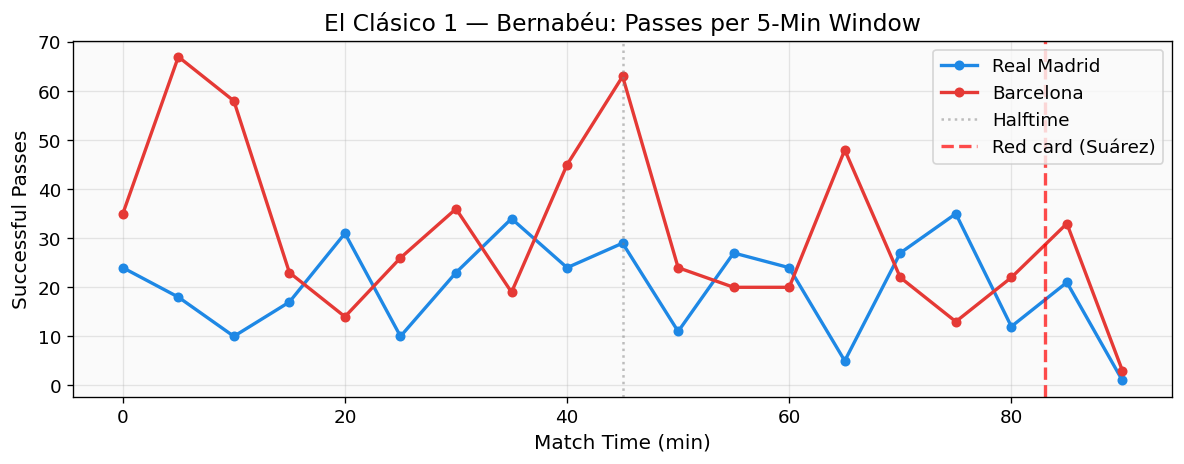

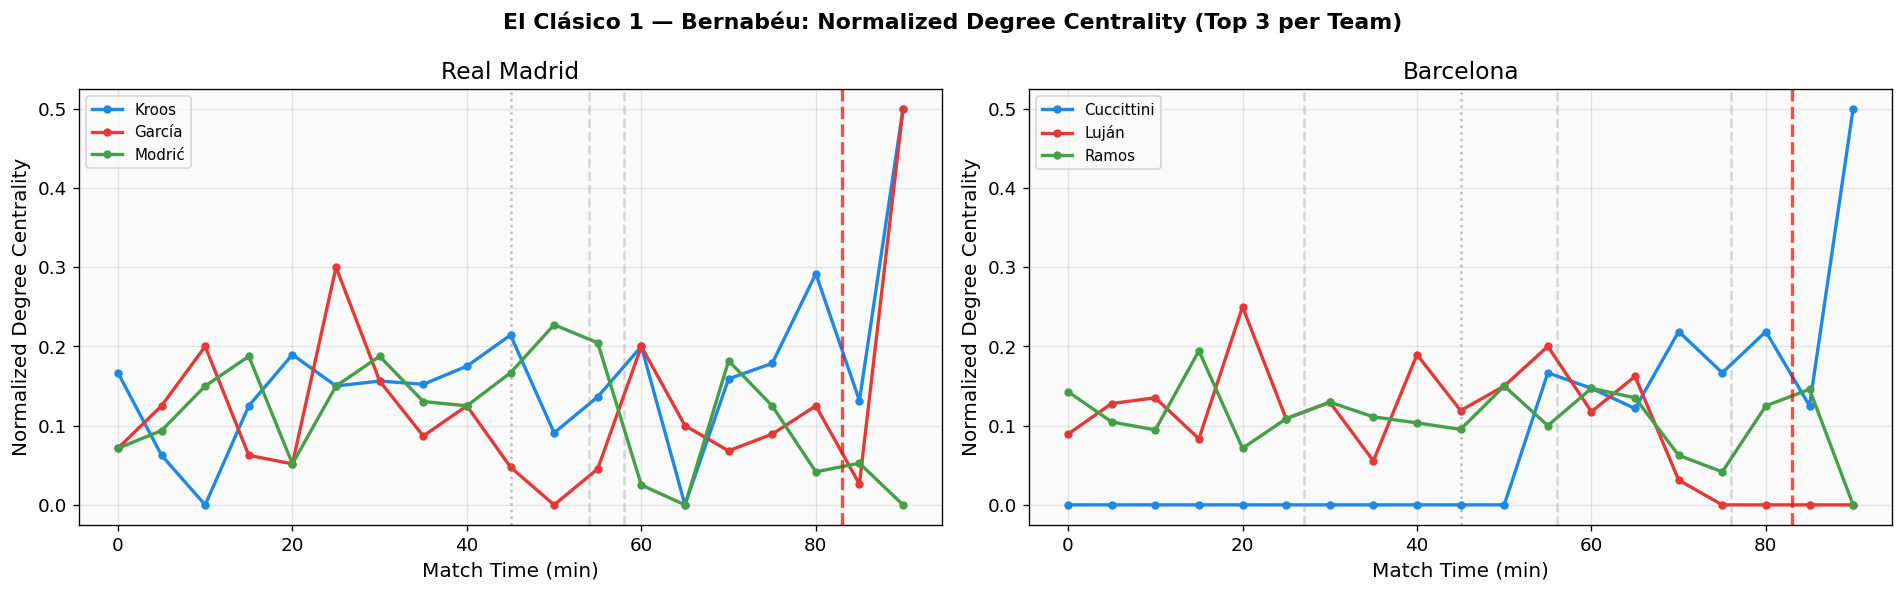

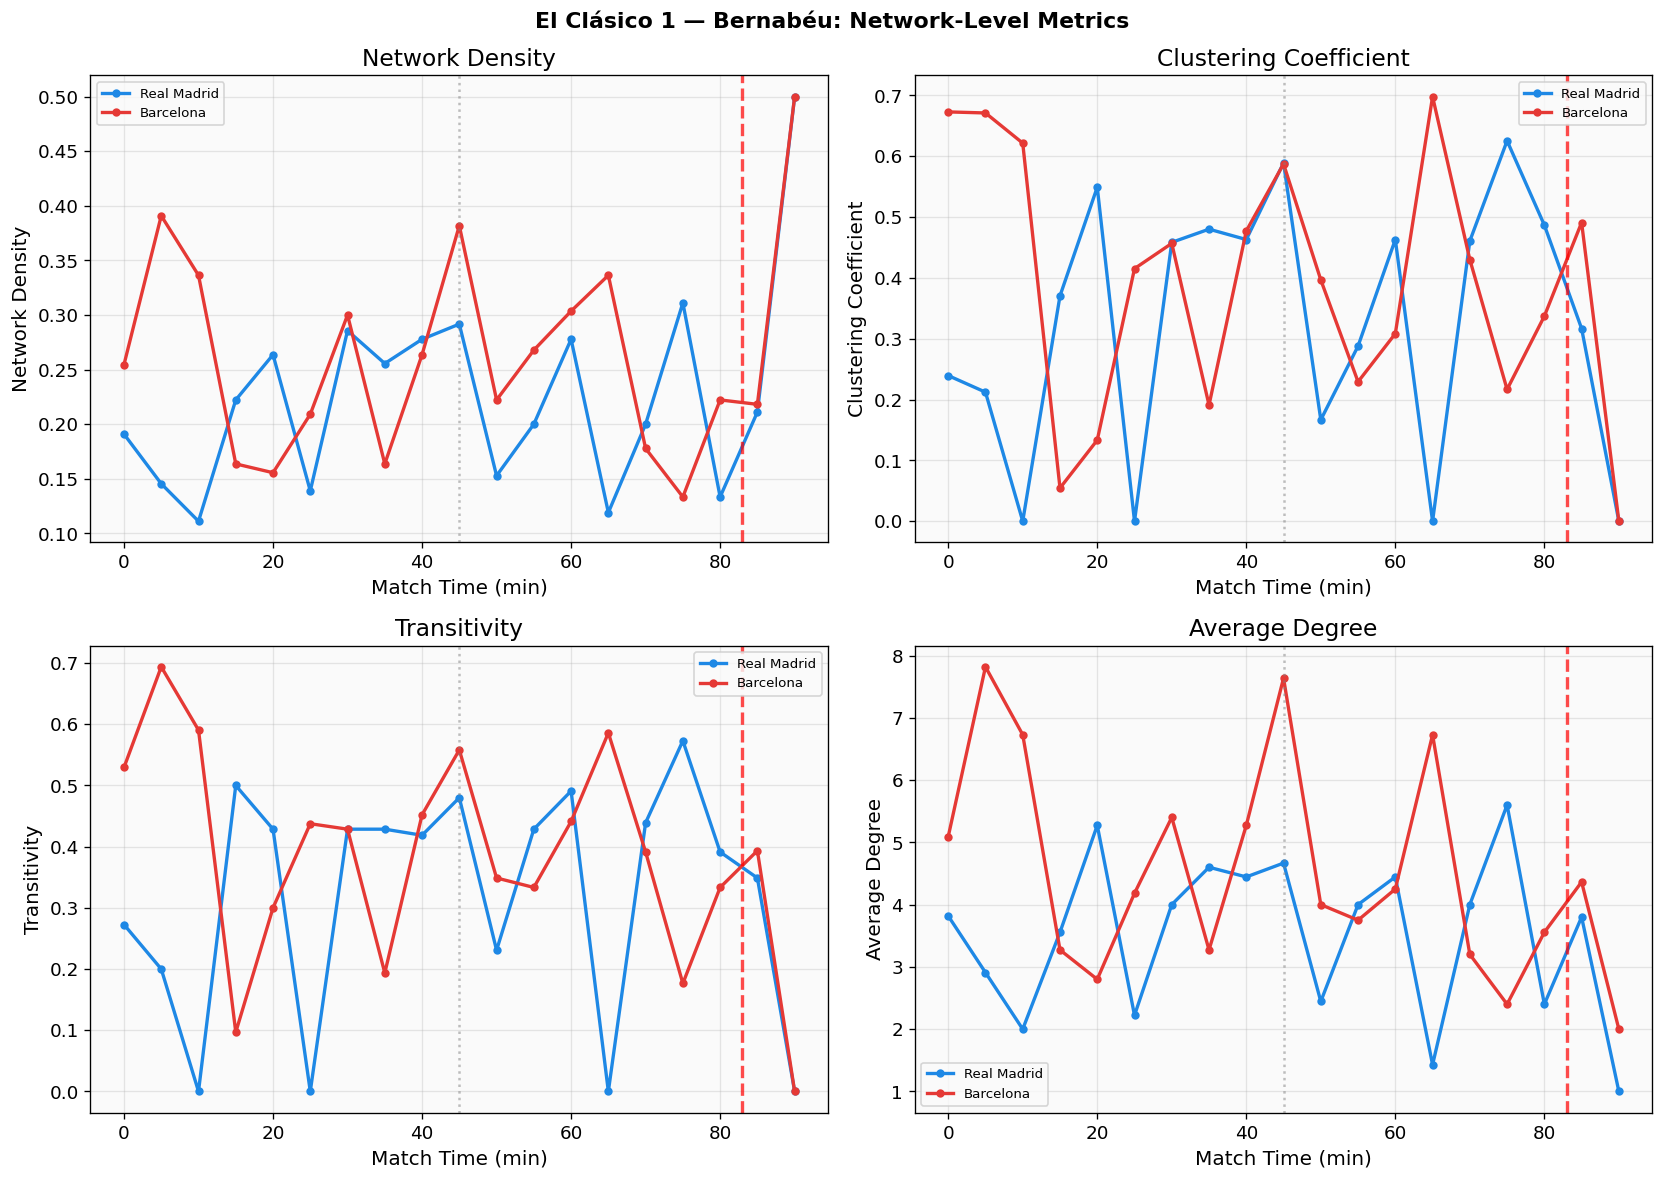

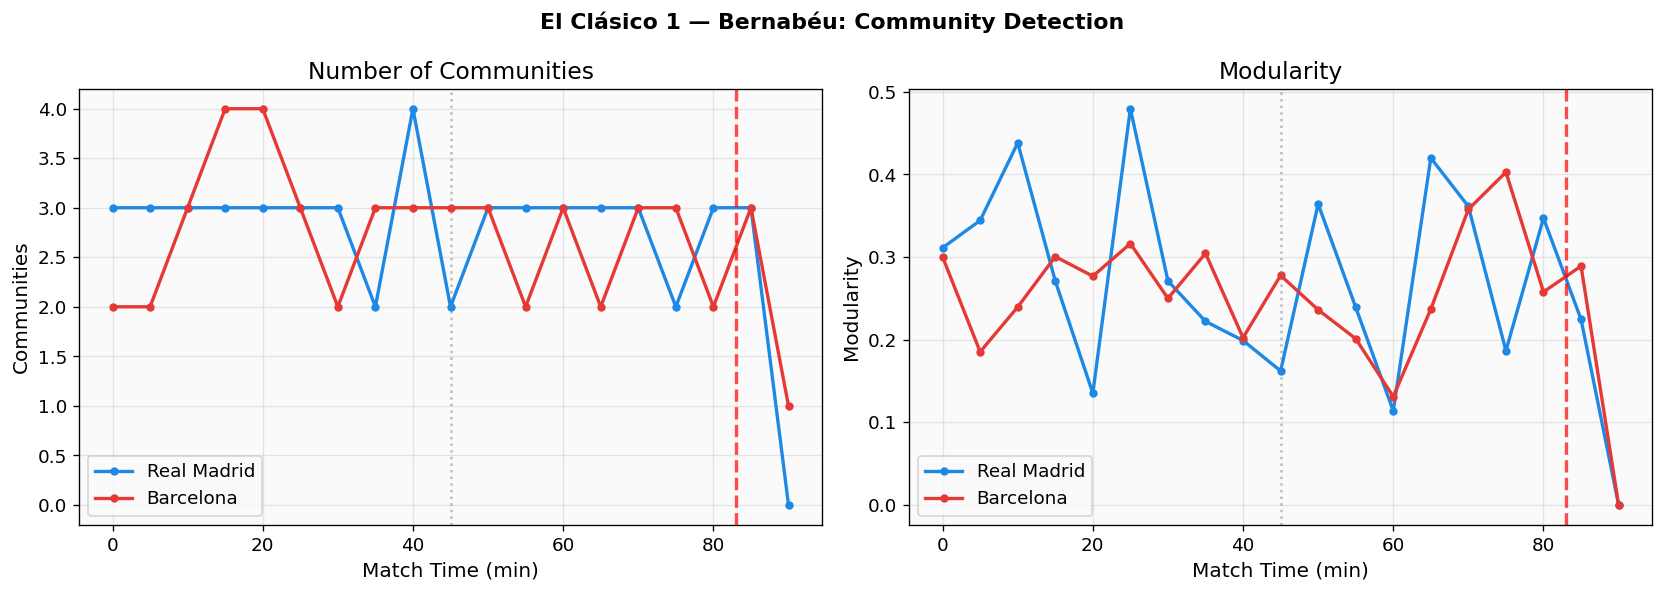

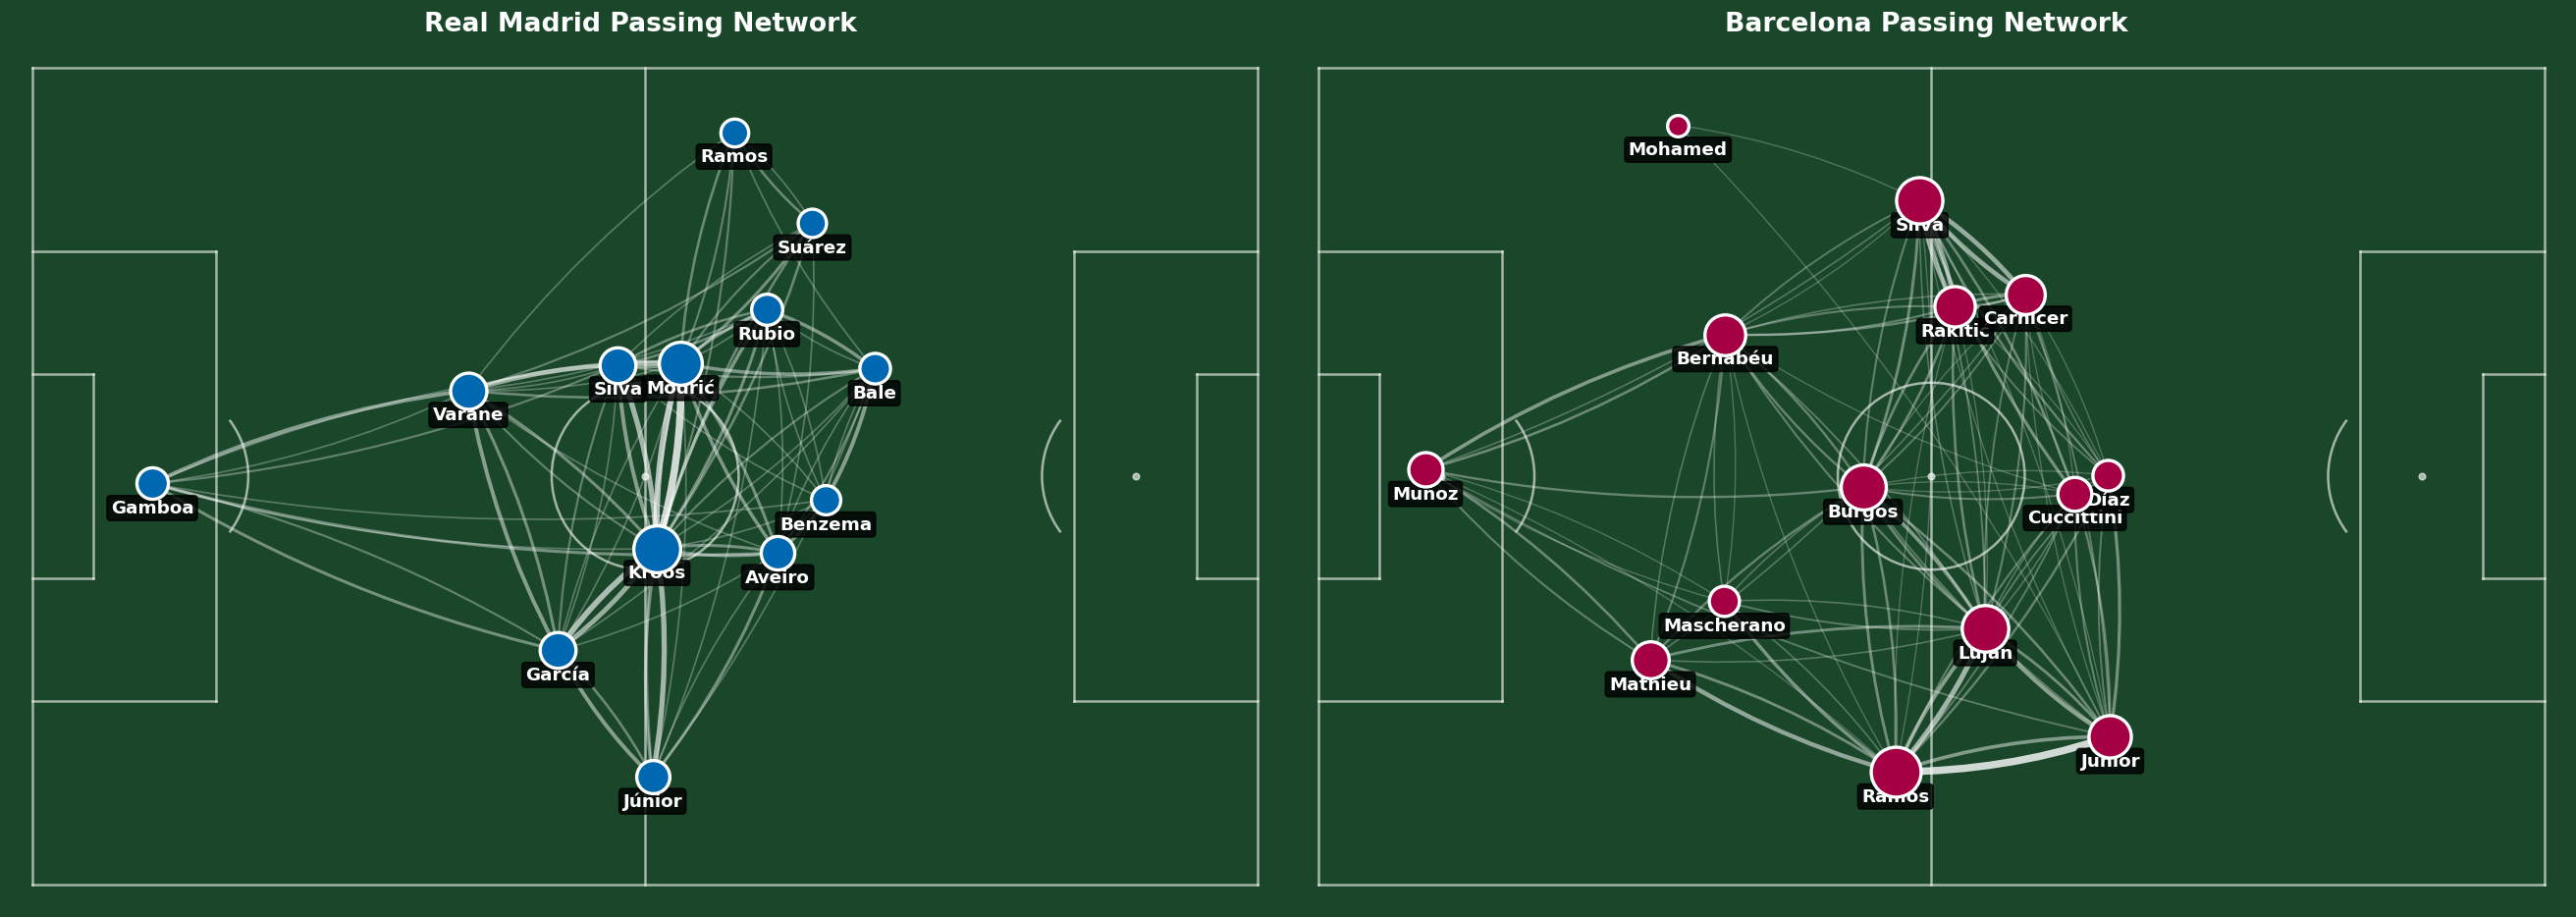


El Clásico 2 — Camp Nou: Barcelona 1-2 Real Madrid
Date: 2016-04-02
Red card: García (Real Madrid) min 82


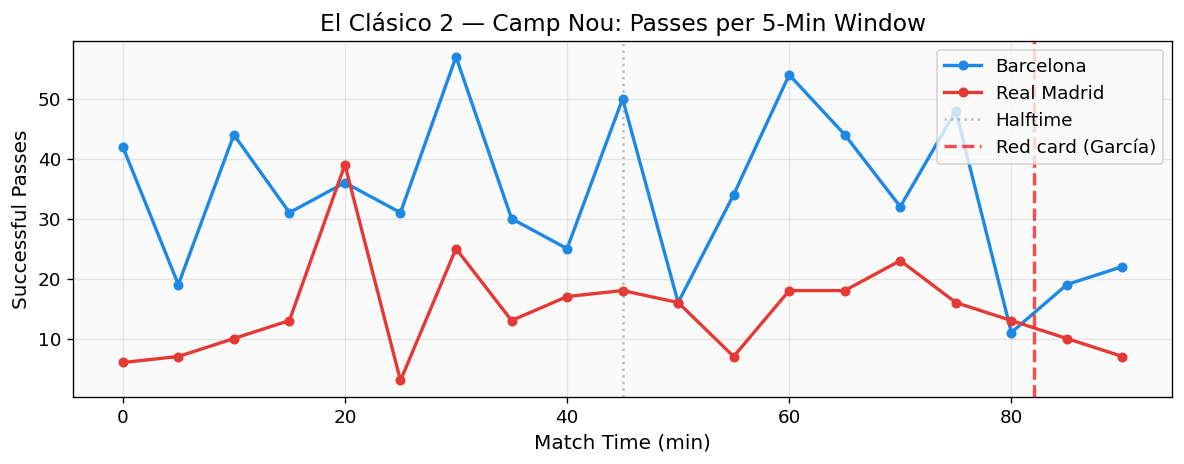

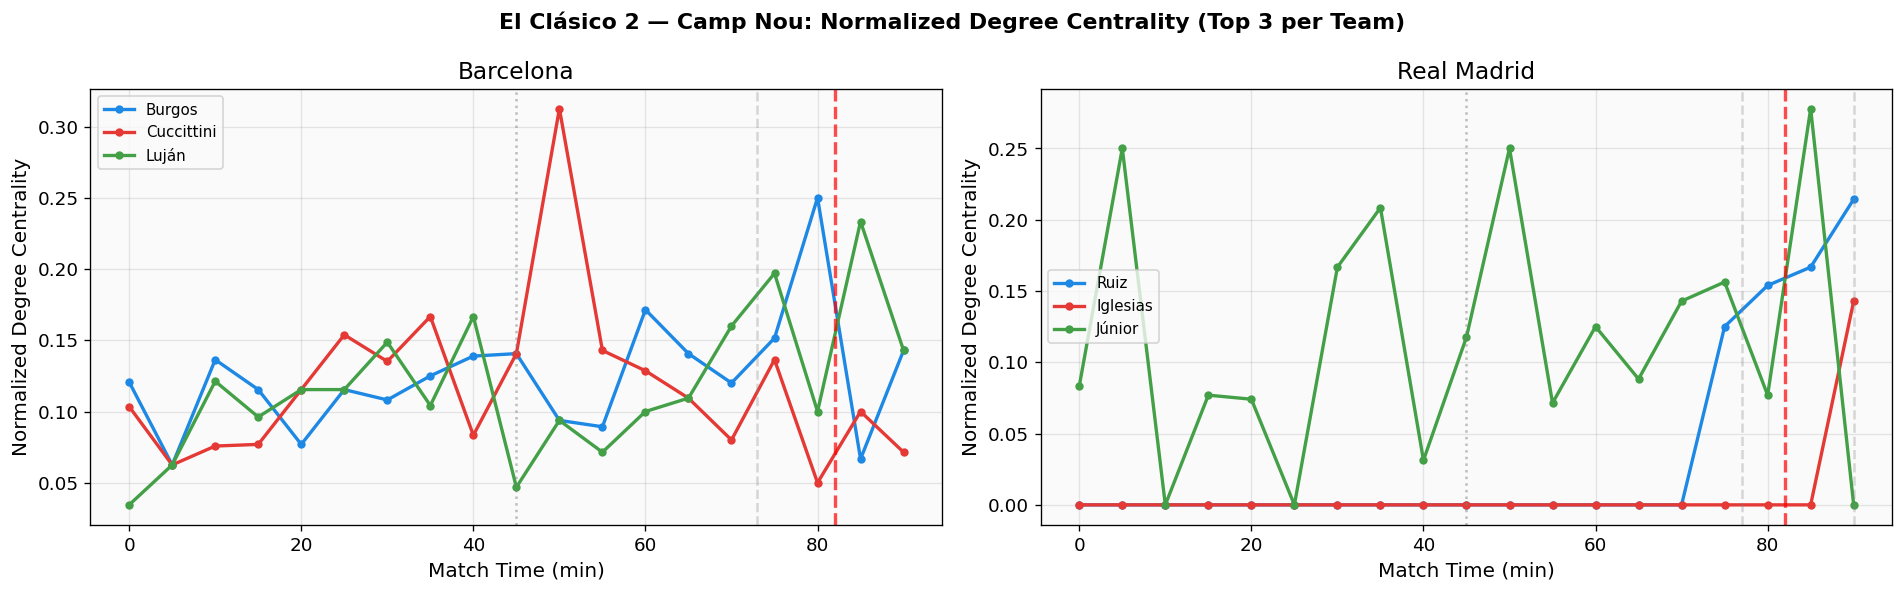

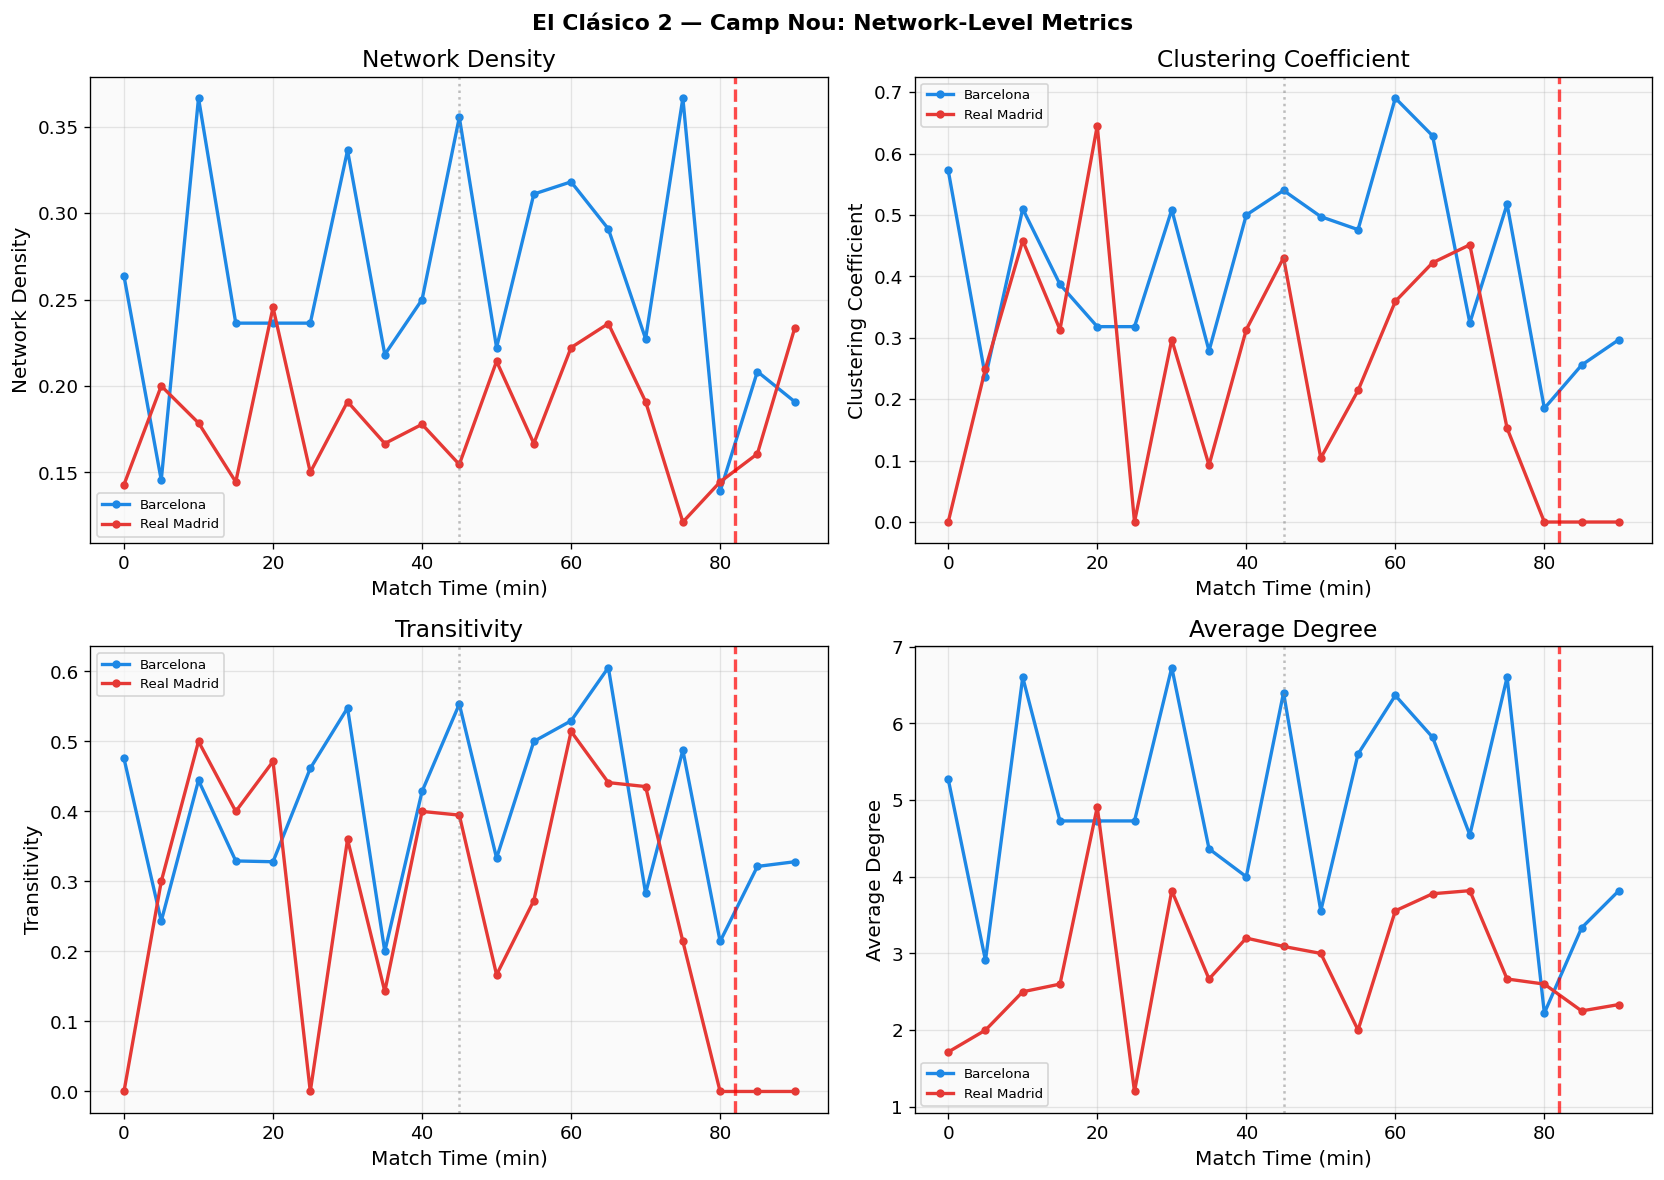

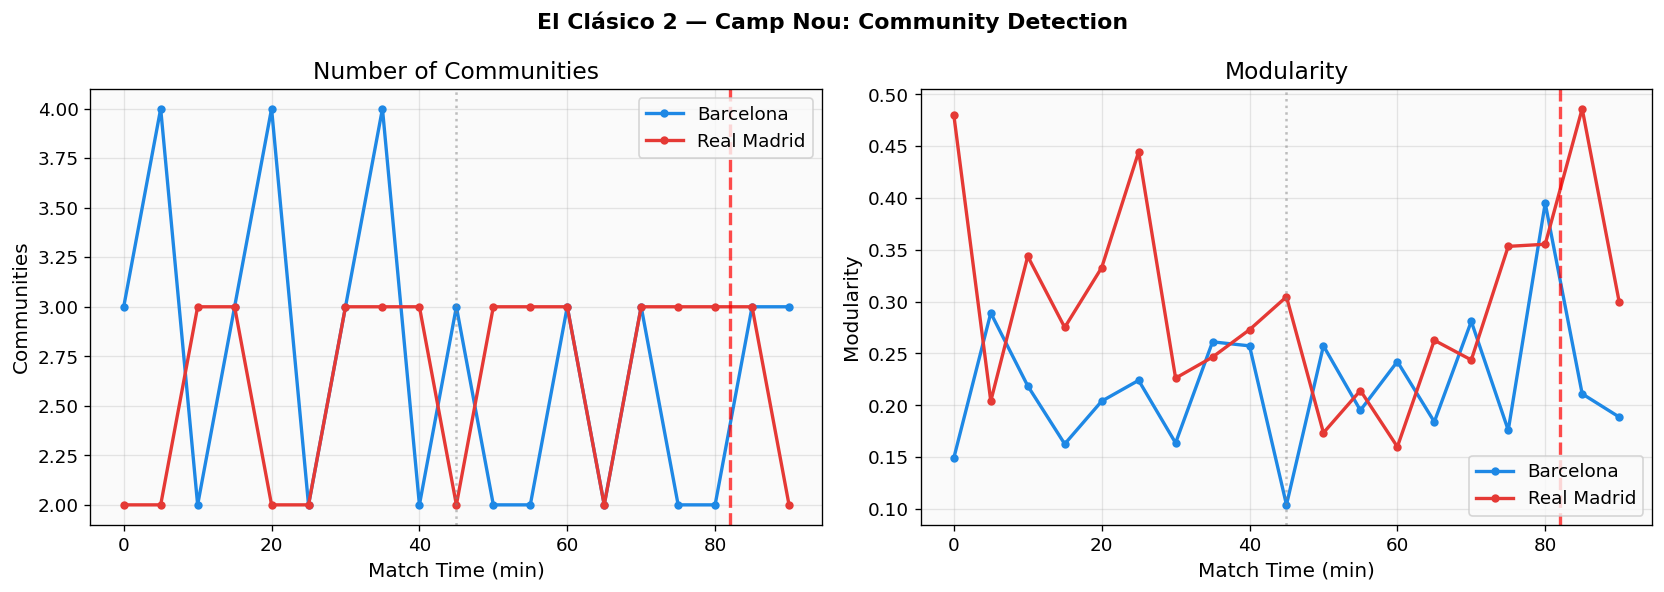

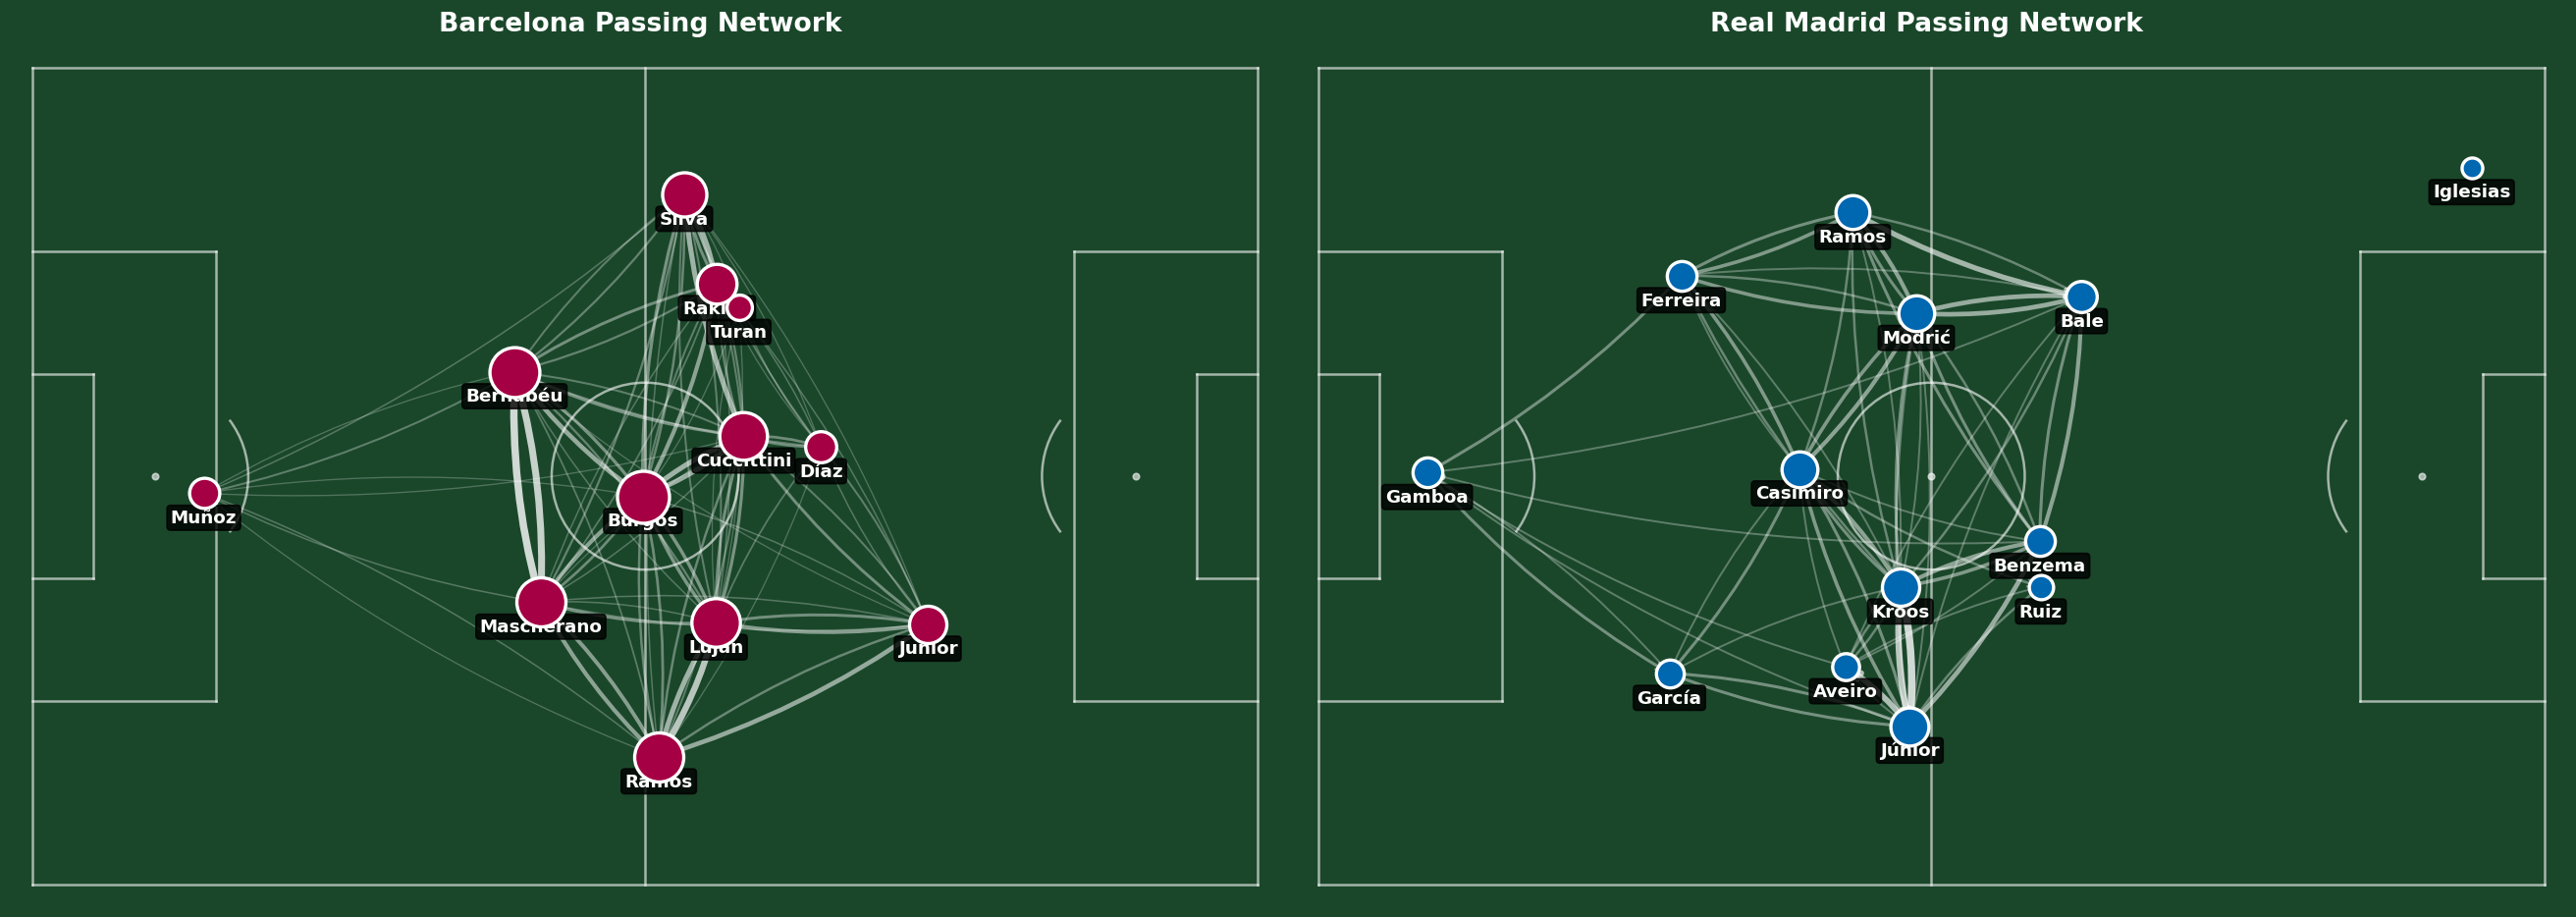

In [18]:
clasico_deep_dive(CLASICO_1, "El Clásico 1 — Bernabéu")
clasico_deep_dive(CLASICO_2, "El Clásico 2 — Camp Nou")

In [19]:
def plot_passing_network(df, team, title_extra="", ax=None, color='#1E88E5', min_passes=2):
    df_t = df[df['team'] == team]
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))
    draw_pitch(ax)

    pos = df_t.groupby('from').agg(x=('loc_x','mean'), y=('loc_y','mean'), n=('loc_x','count'))
    G = build_network(df_t)
    if len(G.edges()) == 0:
        return ax

    max_w = max(d['weight'] for _,_,d in G.edges(data=True))

    for u, v, d in G.edges(data=True):
        if d['weight'] >= min_passes and u in pos.index and v in pos.index:
            w = d['weight']
            lw = 0.5 + (w / max_w) * 4
            alpha = 0.2 + (w / max_w) * 0.6
            ax.annotate('',
                xy=(pos.loc[v,'x'], pos.loc[v,'y']),
                xytext=(pos.loc[u,'x'], pos.loc[u,'y']),
                arrowprops=dict(arrowstyle='->', color='white', lw=lw, alpha=alpha,
                               connectionstyle='arc3,rad=0.08'))

    for player in pos.index:
        size = 150 + pos.loc[player, 'n'] * 10
        ax.scatter(pos.loc[player,'x'], pos.loc[player,'y'],
                  s=size, c=color, edgecolors='white', linewidths=2, zorder=5)
        name = player.split()[-1]
        ax.annotate(name, (pos.loc[player,'x'], pos.loc[player,'y']),
                   xytext=(0,-18), textcoords='offset points', ha='center',
                   fontsize=11, color='white', fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.8))

    ax.set_title(f'{team} Passing Network {title_extra}',
                fontsize=16, fontweight='bold', color='white', pad=10)
    return ax
